In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from episbi.models import deterministic_seir
from episbi.prior import UniformPrior
from episbi.inference import SBIEngine
from episbi import simulate_for_sbi
from episbi.metric import evaluate_prediction_windows
from episbi.utils import plot_prediction_windows

/etc/python/sitecustomize.py:117: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = _original_import(name, globals, locals, fromlist, level)


In [2]:
N  = 100000
E0 = 0
I0 = 10
R0 = 0
S0 = N - E0 - I0 - R0

total_days = 100

init_cond = [S0, E0, I0, R0]

In [3]:
prior = UniformPrior(
    bounds={
        "beta": (0.01, 1.5),
        "kappa": (0.01, 0.5),
        "gamma": (0.01, 0.5),
    }
)

In [4]:
thetas, xs = simulate_for_sbi(
    prior=prior,
    simulator=deterministic_seir,
    num_simulations=10000,
    total_days=total_days,
    seed=0,
    simulator_kwargs={"initial_conditions": init_cond},
)

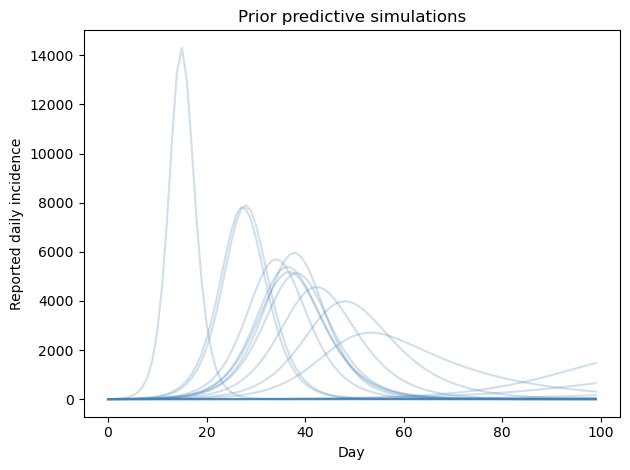

In [5]:
rng = np.random.default_rng(1)
for idx in rng.choice(xs.shape[0], size=20, replace=False):
    plt.plot(xs[idx, :, 0], color="steelblue", alpha=0.25)
plt.xlabel("Day")
plt.ylabel("Reported daily incidence")
plt.title("Prior predictive simulations")
plt.tight_layout()

In [6]:
true_theta = {"beta": 0.80, "kappa": 0.3, "gamma": 0.35}
observed = deterministic_seir(
    true_theta, total_days=total_days,
    initial_conditions=init_cond,
    observation_noise="poisson", seed=0)["data"]

Text(0, 0.5, 'Cases')

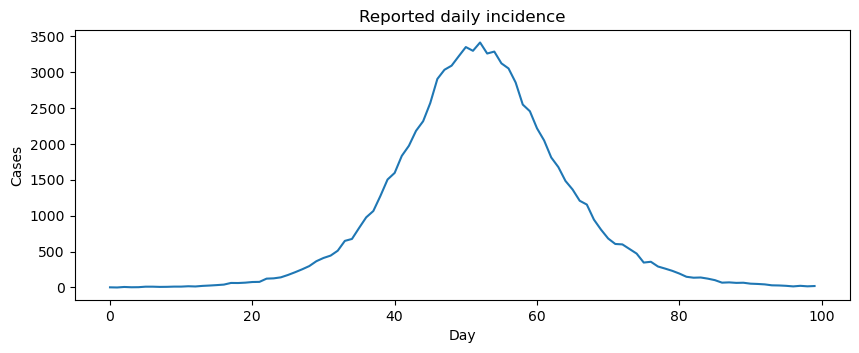

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(observed[:, 0])
ax.set_title("Reported daily incidence")
ax.set_xlabel("Day")
ax.set_ylabel("Cases")

## Inference - NPE-LSTM

In [8]:
inference_days = 100
forecast_days = 0

In [9]:
thetas_train=thetas
xs_train=xs[:,:inference_days]
obs_train = observed[:inference_days]

In [10]:
engine = SBIEngine(batch_size=256)
result = engine.run_npe_lstm(
    obs_data=obs_train.squeeze(-1),
    prior=prior,
    thetas=thetas_train,
    xs=xs_train.squeeze(-1),
    input_dim=1,
    num_samples=1000,
    show_train_summary=False,
)

[*] Running NPE (use_lstm=True) with batch size 256...
 Neural network successfully converged after 326 epochs.

1087it [00:00, 40465.15it/s]            


In [11]:
_, samples = result

In [13]:
posterior_samples = samples

param_df = pd.DataFrame(posterior_samples, columns=prior.names)
param_df.describe()

,beta,kappa,gamma
count,1000.000000,1000.000000,1000.000000
mean,0.871388,0.243434,0.309769
std,0.260430,0.078572,0.079339
min,0.409496,0.136330,0.132431
25%,0.653558,0.181346,0.247220
50%,0.859872,0.220379,0.318264
75%,1.085695,0.285642,0.376599
max,1.488535,0.491770,0.463648


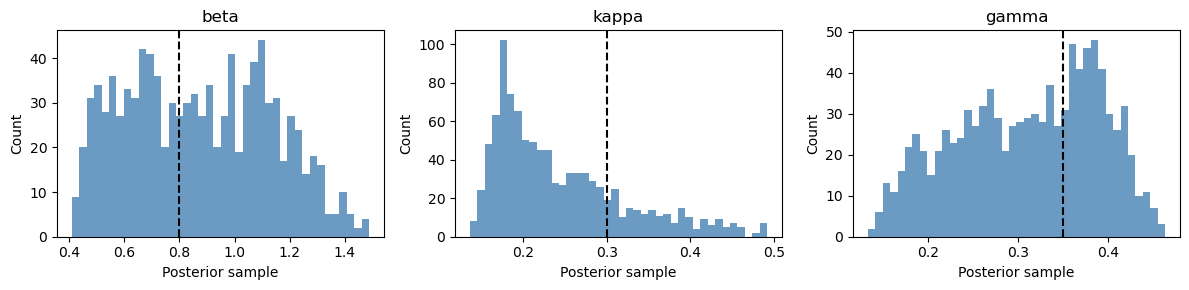

In [14]:
fig, axes = plt.subplots(1, len(prior.names), figsize=(4 * len(prior.names), 3))

if len(prior.names) == 1:
    axes = [axes]

for ax, name in zip(axes, prior.names):
    ax.hist(param_df[name], bins=40, color="steelblue", alpha=0.8)
    ax.axvline(true_theta[name], color="black", linestyle="--", linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel("Posterior sample")
    ax.set_ylabel("Count")

fig.tight_layout()

In [15]:
posterior_predictive = []

for theta in posterior_samples[:300]:
    theta_dict = prior.to_dict(theta)
    sim = deterministic_seir(
        theta_dict,
        total_days=total_days,
        initial_conditions=init_cond,
    )["data"]
    posterior_predictive.append(sim)

posterior_predictive = np.stack(posterior_predictive)

posterior_predictive.shape

(300, 100, 1)

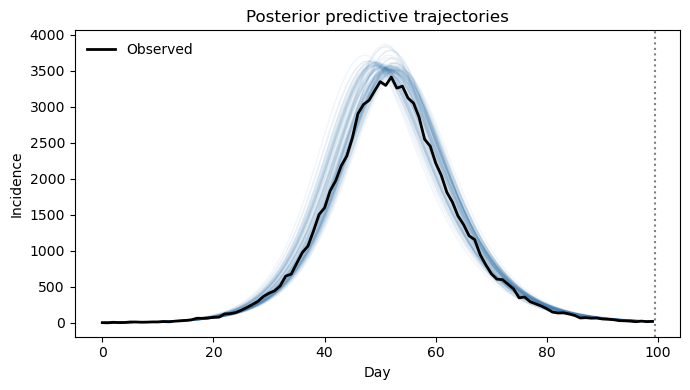

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))

for i in range(min(100, posterior_predictive.shape[0])):
    ax.plot(
        posterior_predictive[i, :, 0],
        color="steelblue",
        alpha=0.08,
        linewidth=1,
    )

ax.plot(observed[:, 0], color="black", linewidth=2, label="Observed")
ax.axvline(inference_days - 0.5, color="gray", linestyle=":")
ax.set_xlabel("Day")
ax.set_ylabel("Incidence")
ax.set_title("Posterior predictive trajectories")
ax.legend(frameon=False)
fig.tight_layout()

/home/gjang12/.conda/envs/sbi_env/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gjang12/.conda/envs/sbi_env/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


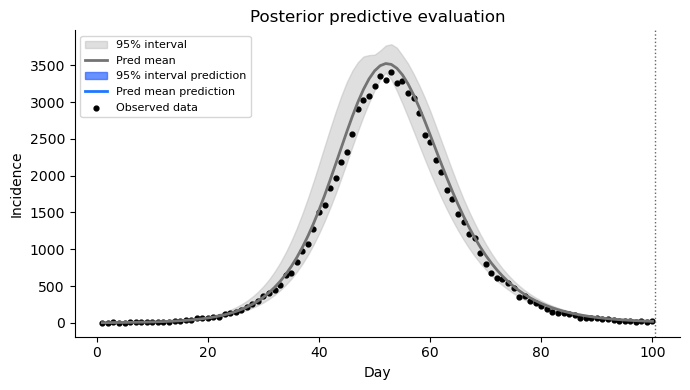

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))

plot_prediction_windows(
    observed,
    posterior_predictive,
    inference_days=inference_days,
    forecast_days=forecast_days,
    ylabel="Incidence",
    title="Posterior predictive evaluation",
    ax=ax,
)

fig.tight_layout()

In [18]:
ppc_result = evaluate_prediction_windows(
    y_obs=observed,
    prediction=posterior_predictive,
    inference_days=inference_days,
    forecast_days=forecast_days,
    output_names=["incidence"],
)

ppc_result

,window,output,MAE,RMSE,PI95_coverage,interval_score,WIS
0,inference,incidence,55.832436,88.081619,0.75,402.242376,140.019521
1,forecast,incidence,NaN,NaN,NaN,NaN,NaN
